## Build a basic chatbot with langgraph (Graph API) ##

In [15]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages

In [16]:
class State(TypedDict):
    #messages have the type "list".the add_messages function
    #int hte annotation defines how this state key should e updated
    #(in this case, it apends messages to the list, rather than overwriting them)
    messages:Annotated[list, add_messages]

graph_builder=StateGraph(State)

In [17]:
graph_builder

In [18]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [19]:
from langchain_groq import ChatGroq 
from langchain.chat_models import init_chat_model

llm = ChatGroq(model="llama-3.1-8b-instant")

In [20]:
llm

ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x00000293F5D74640>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000293F5D74FC0>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [21]:
llm = init_chat_model("groq:llama-3.1-8b-instant")
llm

ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x00000293F5D75A70>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000293F5D763F0>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [22]:
##Node Functionality
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

In [23]:
graph_builder=StateGraph(State)

##adding nodes
graph_builder.add_node("llmchatbot",chatbot)

##adding edges
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)

## compile this graph
graph = graph_builder.compile()

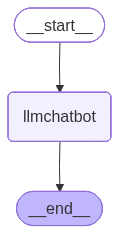

In [24]:
## visualise the graph
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [25]:
response = graph.invoke({"messages":"Hi"})

In [26]:
response["messages"][-1].content

"It's nice to meet you. Is there something I can help you with or would you like to chat?"

In [27]:
for event in graph.stream({"messages":"Hi how are you?"}):
    for value in event.values():
        print(value["messages"][-1].content)


I'm doing well, thank you for asking. I'm a large language model, so I don't have emotions or feelings like humans do, but I'm here to assist you with any questions or information you might need. How can I help you today?


## Tool Calling Chatbot ##

In [28]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results=2)
tool.invoke("what is langraph?")

{'query': 'what is langraph?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.datacamp.com/tutorial/langgraph-tutorial',
   'title': 'LangGraph Tutorial: What Is LangGraph and How to Use It?',
   'content': "# LangGraph Tutorial: What Is LangGraph and How to Use It? LangGraph is a library within the LangChain ecosystem that provides a framework for defining, coordinating, and executing multiple LLM agents (or chains) in a structured and efficient manner. Imagine you're building a complex, multi-agent large language model (LLM) application. It's exciting, but it comes with challenges: managing the state of various agents, coordinating their interactions, and handling errors effectively. LangGraph provides a framework for defining, coordinating, and executing multiple LLM agents (or chains) in a structured manner. The core concepts of LangGraph include: graph structure, state management, and coordination. In LangGraph, each node represents

In [31]:
## Custom function
def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: First integer.
        b: Second integer.

    Returns:
        Product of a and b.
    """
    return a * b

In [32]:
tools = [tool,multiply]

In [33]:
llm_with_tool = llm.bind_tools(tools)

In [34]:
llm_with_tool

_ChatModelBinding(bound=ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x00000293F5D75A70>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000293F5D763F0>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool deliver

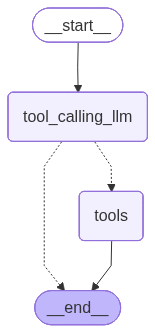

In [35]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## grpah
builder = StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

##adding edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",

# if the latest message (result) from assistant is a tool call -> tool_condition routes to tool
# if the latest message (result) from assistant is a not a tool call -> tools_condition routes to end
    tools_condition
)
builder.add_edge("tools",END)

##compile the graph
graph = builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [38]:
response = graph.invoke({"messages":"what is the recent AI news?"})

In [39]:
response["messages"][-1].content

'{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://amp.scmp.com/news/china/politics/article/3357005/surge-ai-related-court-cases-fuels-calls-china-clarify-its-laws", "title": "Surge in AI-related court cases fuels calls for China to clarify its laws - South China Morning Post", "score": 0.6755297, "published_date": "Sun, 14 Jun 2026 04:00:13 GMT", "content": "# Surge in AI-related court cases fuels calls for China to clarify its laws. Growing number of tech-related cases has increased calls for a comprehensive legal framework to govern the technology. The Chinese legal system is grappling with a surge of artificial intelligence cases, but experts have warned that the lack of a unified legislative framework is hampering efforts to tackle the problem. In a recent landmark case, a court in the eastern city of Hangzhou ruled against a tech company that had fired one of its workers after he refused to accept a demotion and pa

In [40]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

what is the recent AI news?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (vq88f9cx2)
 Call ID: vq88f9cx2
  Args:
    query: recent AI news
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://amp.scmp.com/news/china/politics/article/3357005/surge-ai-related-court-cases-fuels-calls-china-clarify-its-laws", "title": "Surge in AI-related court cases fuels calls for China to clarify its laws - South China Morning Post", "score": 0.6755297, "published_date": "Sun, 14 Jun 2026 04:00:13 GMT", "content": "# Surge in AI-related court cases fuels calls for China to clarify its laws. Growing number of tech-related cases has increased calls for a comprehens

In [43]:
response = graph.invoke({"messages":"What is 2 multiply by 5?"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is 2 multiply by 5?
================================== Ai Message ==================================
Tool Calls:
  multiply (0d4dpb591)
 Call ID: 0d4dpb591
  Args:
    a: 2
    b: 5
================================= Tool Message =================================
Name: multiply

10


In [44]:
response = graph.invoke({"messages":"What is 2 multiply by 5 and them multiply by 7?"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is 2 multiply by 5 and them multiply by 7?
================================== Ai Message ==================================
Tool Calls:
  multiply (zmvmr0n19)
 Call ID: zmvmr0n19
  Args:
    a: 2
    b: 5
  multiply (zzxvam7xv)
 Call ID: zzxvam7xv
  Args:
    a: 35
    b: 7
================================= Tool Message =================================
Name: multiply

10
================================= Tool Message =================================
Name: multiply

245


In [45]:
response = graph.invoke({"messages":"Give me the recent news of ongoing war between USA and Iran and then multiply by 7?"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Give me the recent news of ongoing war between USA and Iran and then multiply by 7?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (yxm14bk81)
 Call ID: yxm14bk81
  Args:
    query: USA Iran war recent news
    topic: news
  multiply (xaq2tez3c)
 Call ID: xaq2tez3c
  Args:
    a: 10
    b: 7
================================= Tool Message =================================
Name: tavily_search

{"query": "USA Iran war recent news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.nytimes.com/live/2026/06/12/world/iran-war-trump-us-israel", "title": "Iran War Live Updates: Tense Calm Grips Mideast as Trump Again Claims Deal Is Close - The New York Times", "score": 0.7646988, "published_date": "Fri, 12 Jun 2026 09:26:39 GMT", "content": "# Iran War Live Updates: Trump Claims a Deal Is Close as Tense Calm Gr